In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles, make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
)
from sklearn.metrics import f1_score

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def plot_scatters_of_fit(clf_fit):
    fig, ax = plt.subplots(1, 3, figsize=(20, 8))
    sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test, ax=ax[0])
    sns.scatterplot(
        x=X_test[:, 0], y=X_test[:, 1], hue=clf_fit.predict(X_test), ax=ax[1]
    )
    sns.scatterplot(
        x=X_test[:, 0], y=X_test[:, 1], hue=clf_fit.predict(X_test) == y_test, ax=ax[2]
    )

    for axes, title_ in zip(
        ax, ["True classes", "Predicted classes", "Correct-incorrect classification"]
    ):
        axes.set_title(title_)
        axes.legend(loc=1, prop={"size": 15})

    return None

In [3]:
data = make_circles(n_samples=10000, noise=0.075, random_state=101)

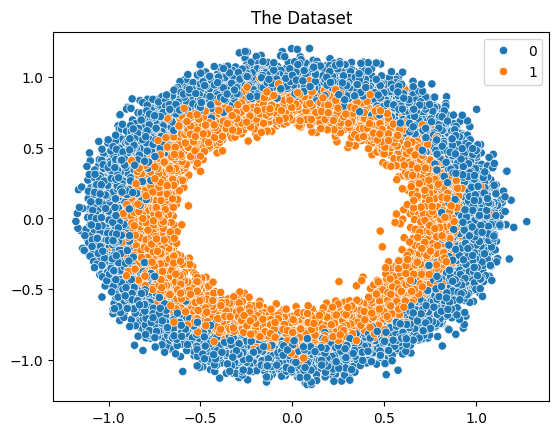

In [ ]:
sns.scatterplot(x=data[0][:, 0], y=data[0][:, 1], hue=data[1])
plt.title("The Dataset")
plt.show()

In [ ]:
X = data[0]
y = data[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Text(0.5, 1.0, 'Train set')

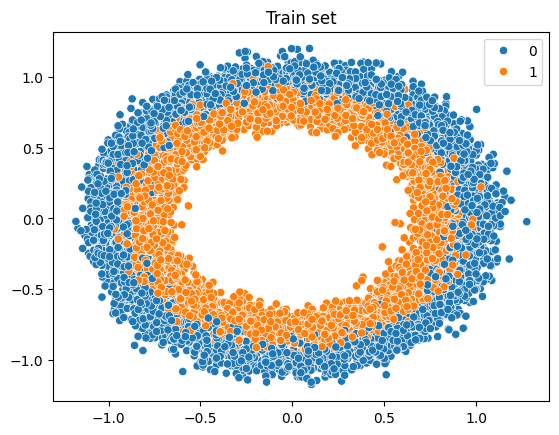

In [ ]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train)
plt.title("Train set")

Text(0.5, 1.0, 'Test set')

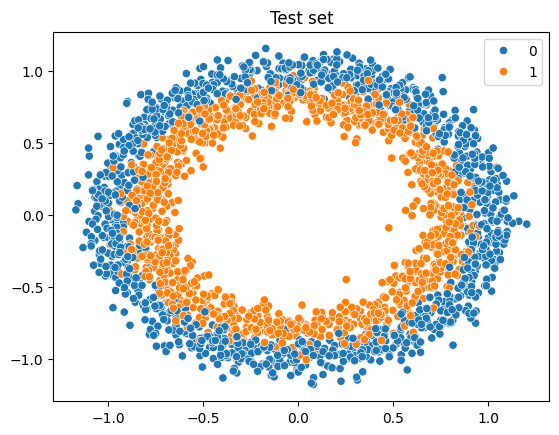

In [ ]:
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test)
plt.title("Test set")

## SIMPLE DECISION TREE

In [ ]:
base_tree = DecisionTreeClassifier(criterion="gini", max_depth=1, random_state=101)
base_tree_fit = base_tree.fit(X_train, y_train)

In [10]:
f1_score(y_train, base_tree_fit.predict(X_train))

0.6958171298491891

In [11]:
f1_score(y_test, base_tree_fit.predict(X_test))

0.696578799775659

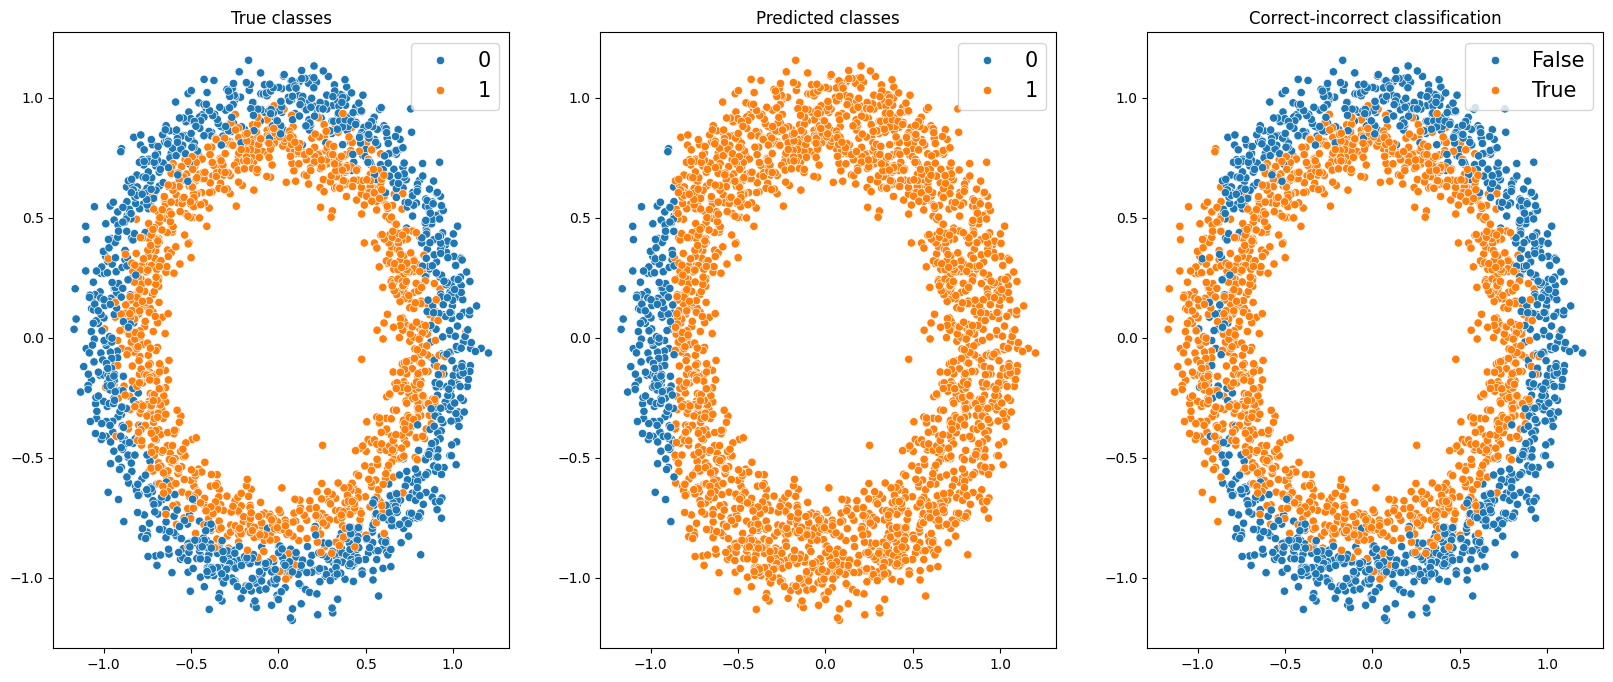

In [12]:
plot_scatters_of_fit(base_tree_fit)

## BAGGING

In [16]:
baggingclass = BaggingClassifier(base_tree, 100, random_state=101)
baggingclass_fit = baggingclass.fit(X_train, y_train)

In [17]:
f1_score(y_train, baggingclass_fit.predict(X_train))

0.728749873057784

In [18]:
f1_score(y_test, baggingclass_fit.predict(X_test))

0.7342615012106537

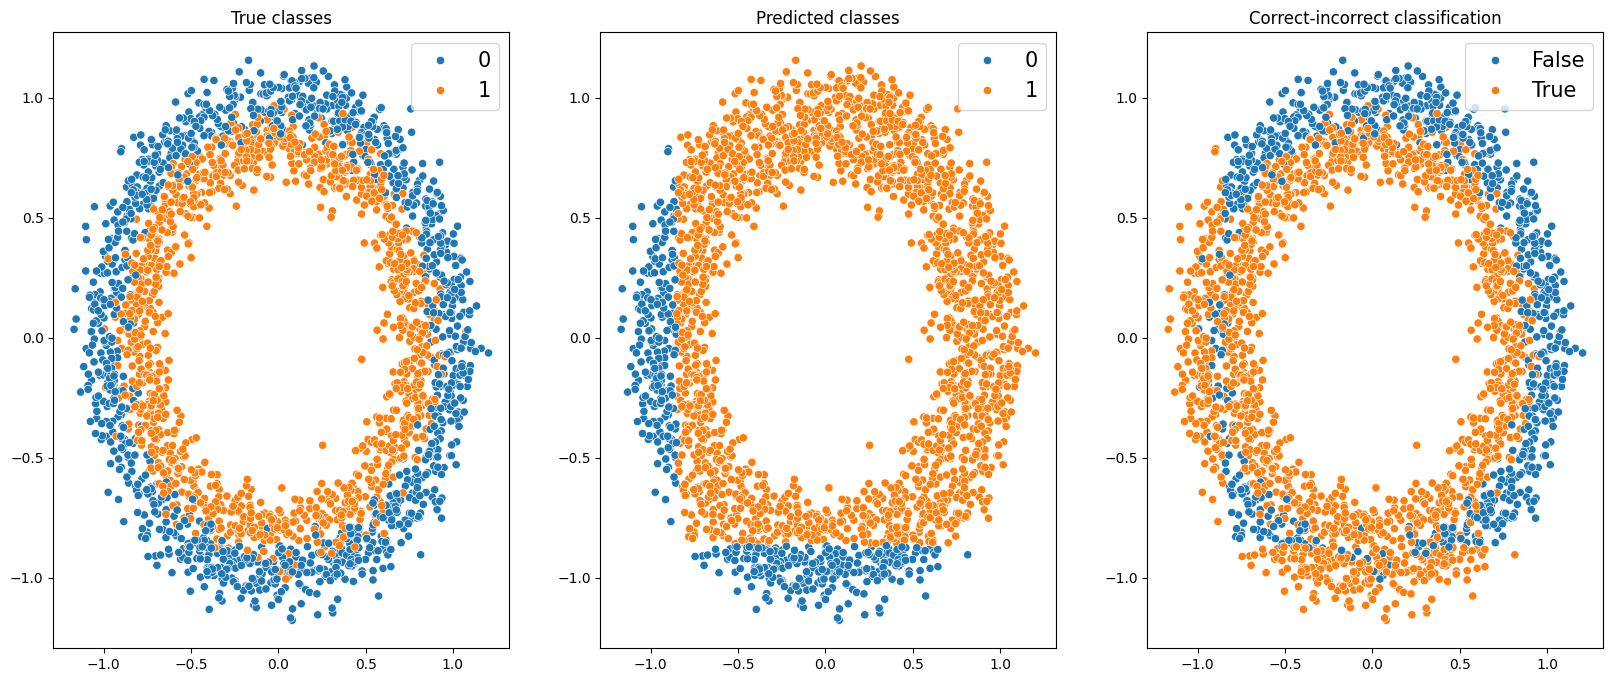

In [19]:
plot_scatters_of_fit(baggingclass_fit)

## RANDOM FOREST

In [20]:
# a special case for bagging
randomforest = RandomForestClassifier(
    100, criterion="gini", max_depth=1, random_state=101
)
randomforest_fit = randomforest.fit(X_train, y_train)

In [21]:
f1_score(y_train, randomforest_fit.predict(X_train))

0.7658643326039387

In [22]:
f1_score(y_test, randomforest_fit.predict(X_test))

0.7736033975824894

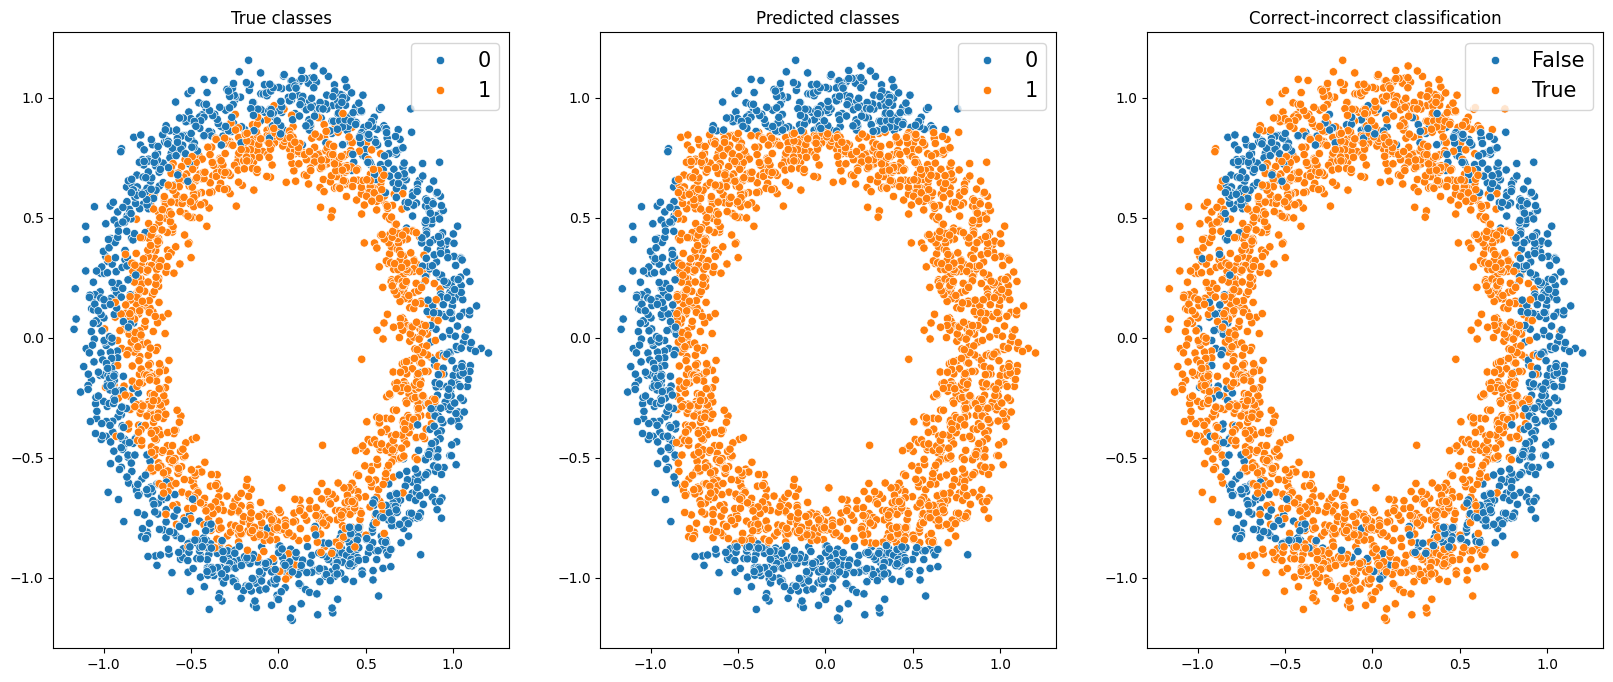

In [23]:
plot_scatters_of_fit(randomforest_fit)

### RANDOM FOREST AS BAGGING CLASSIFIER

In [24]:
random_forest_mod = RandomForestClassifier(
    100, criterion="gini", max_depth=1, random_state=101, max_features=1.0
)

In [25]:
random_forest_modfit = random_forest_mod.fit(X_train, y_train)

In [26]:
f1_score(y_train, random_forest_modfit.predict(X_train))

0.728749873057784

In [27]:
f1_score(y_test, random_forest_modfit.predict(X_test))

0.7342615012106537

In [28]:
f1_score(y_train, random_forest_modfit.predict(X_train)) == f1_score(
    y_train, baggingclass_fit.predict(X_train)
)

True

## BOOSTING

In [29]:
adaboost = AdaBoostClassifier(estimator=base_tree, n_estimators=100, random_state=101)
adaboost_fit = adaboost.fit(X_train, y_train)

c:\Users\aronn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [30]:
f1_score(y_train, adaboost_fit.predict(X_train))

0.9007045061810448

In [31]:
f1_score(y_test, adaboost_fit.predict(X_test))

0.9016459253311923

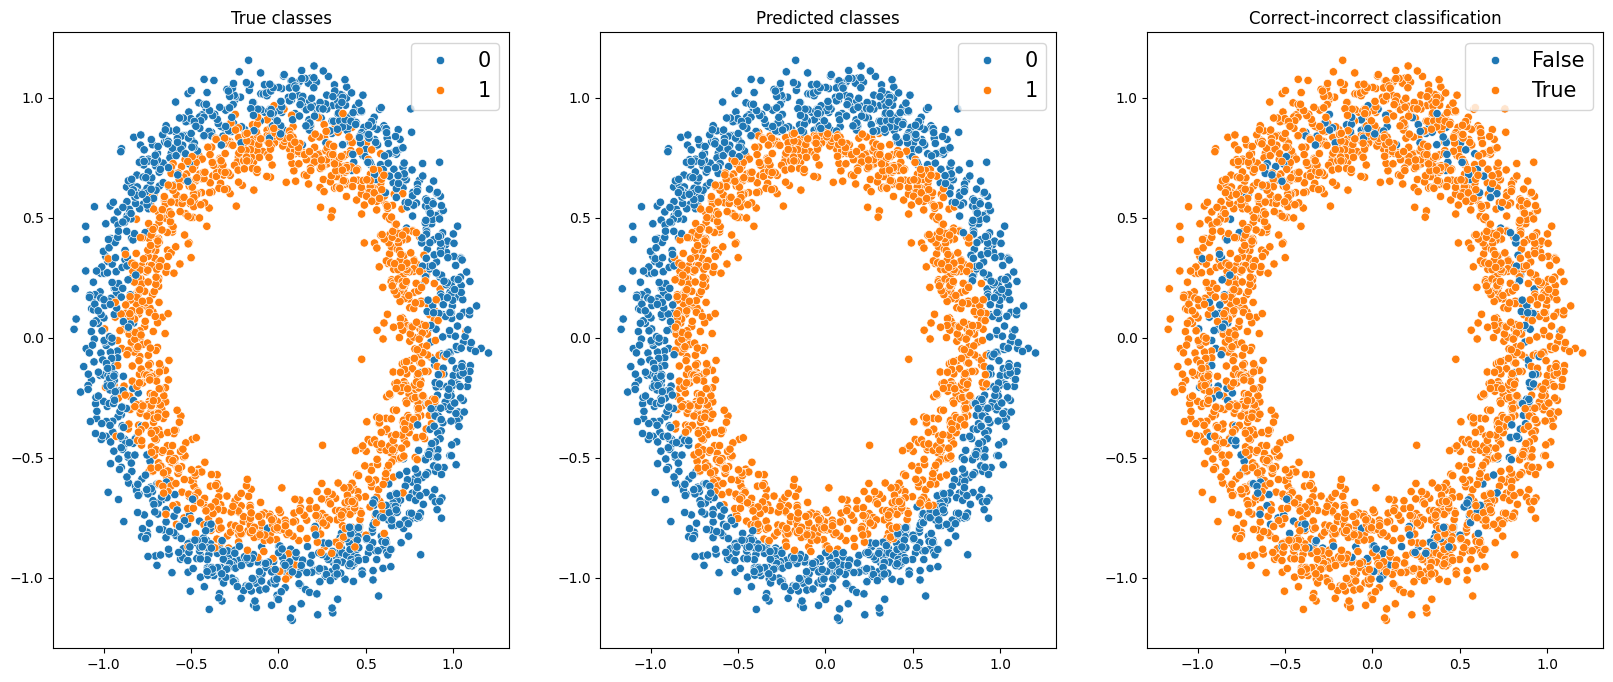

In [32]:
plot_scatters_of_fit(adaboost_fit)

### Mandatory:

- Create train and test set for the data below
- Fit a boosting classifier to the data (used hyperparameter values are up to you)
- Make a similar chart as used for the circles data (showing true, predicted and correct-incorrect classification)
- Run the classifier multiple times, each time increasing the number of estimators used (go at least as high as 200-300 estimators)
    - For each model save an appropriate performance score
- Create a plot showing the relationship between the number of estimators and the value of the performance score on the train and test set

### Optional

- Achieve the best possible (test set) fit on
    - Any type of hyperparameter optimization is allowed
- This optional homework is graded in the following manner. The model with the best fit gets n points, second best n-1, and so on ... (n being the number of students who submitted the optional task)

In [45]:
X, y = make_moons(n_samples=3000, noise=0.6, random_state=42)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)